In [1]:
from ib_insync import *
from datetime import datetime, timedelta
import time
import pandas as pd
import math
import matplotlib.pyplot as plt
import mplfinance as mpf
import numpy as np
import logging
from IPython.display import display, clear_output


c:\Users\diego\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\diego\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


usuario IB-TWS: robotr923 passwd: robotrader2025 

In [2]:
util.startLoop() 
# Crea un objeto IB
ib = IB()
# se conecta a IB en localhost con el puerto a elegir
ib.connect('127.0.0.1', 7498, clientId =72)
ib.reqMarketDataType(3)
print("Conectando a IB...", ib)


Conectando a IB... <IB connected to 127.0.0.1:7498 clientId=72>


In [ ]:
#variables iniciales
av_period = 10
quantity = 25000 
atr_period = 5
risk_multiple = 1.5
breakeven_trigger = 0.0005

In [ ]:
def utils(bars):
    "Convierte las barras de IB a un DataFrame de pandas."
    if not bars:
        log("Error: No se recibieron barras de IB. Verifica la conexión o el símbolo.")
        return None
    df = util.df(bars)
    return df

def date(df):
    "Asegura que la columna 'date' esté en formato datetime y ordena el DataFrame por fecha."
    if df is None or df.empty:
        return None
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date'])
    df.set_index('date', inplace=True)
    df.sort_index(inplace=True)
    return df
logging.basicConfig(
    filename='logs/log_base.log',
    level=logging.INFO,
    format='%(asctime)s | %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
def log(msg):
    "Registra un mensaje tanto en la consola como en el archivo de log."
    print(msg)
    logging.info(msg)


In [ ]:
def modo_trabajo(x=1):
    "Determina el modo de trabajo: 1 para IB, otro para CSV. Devuelve un DataFrame con los datos y el contrato de IB."
    if x == 1:
        # Cambio de exchange a IDEALPRO (estándar para Forex en IB)
        div_contract = Forex('USDCAD', exchange='IDEALPRO') 
        ib.qualifyContracts(div_contract) # Valida que el contrato sea correcto
        
        bars_div = ib.reqHistoricalData(
            div_contract,
            endDateTime='',
            durationStr='15 D', 
            barSizeSetting='1 min',
            whatToShow='MIDPOINT',
            useRTH=False,
            formatDate=1
        )
        
        # Pausa breve para asegurar recepción
        ib.sleep(1) 
        
        df_div = utils(bars_div)
        df_div = date(df_div)
        
        if df_div is not None:
            log('Modo de trabajo: IB - Datos cargados con éxito')
        else:
            log('Error: No se pudieron obtener datos de IB')
    else:
        try:
            df_div = pd.read_csv("datos_8.csv")
            df_div = date(df_div)
            div_contract = Forex('USDCAD', exchange='IDEALPRO')
            log('Modo de trabajo: CSV')
        except FileNotFoundError:
            log("Error: No se encontró el archivo CSV")
            return None
            
    return df_div,div_contract

In [ ]:
# Ejecutar el modo de trabajo
df_div,div_contract=modo_trabajo(1)

Modo de trabajo: IB - Datos cargados con éxito


In [ ]:
# Guardar el DataFrame a CSV
df_div.to_csv('data.csv', index=True)

In [ ]:
# Mostrar las primeras filas del DataFrame
df_div.head()

,open,high,low,close,volume,average,barCount
date,,,,,,,
2026-02-19 17:15:00-05:00,1.368375,1.36844,1.368355,1.368425,-1.0,-1.0,-1
2026-02-19 17:16:00-05:00,1.368425,1.36844,1.368425,1.368435,-1.0,-1.0,-1
2026-02-19 17:17:00-05:00,1.368435,1.36844,1.368425,1.368430,-1.0,-1.0,-1
2026-02-19 17:18:00-05:00,1.368430,1.36843,1.368310,1.368320,-1.0,-1.0,-1
2026-02-19 17:19:00-05:00,1.368320,1.36832,1.368320,1.368320,-1.0,-1.0,-1


In [ ]:
def velas(df,av_period=10):
    "Genera un gráfico de velas con una media móvil simple (SMA) superpuesta."
    "Parámetros:\n"
    "df: DataFrame con los datos de precios (debe contener una columna 'close')"
    "av_period: Número de períodos para calcular la media móvil (default=10)"
    # 1. Cálculo de la Media Móvil (usando av_period = 10 de tu notebook)
    
    df['SMA'] = df['close'].rolling(window=av_period).mean()

    # 2. Visualización interesante
    # Vamos a graficar los últimos 60 días para que las velas se vean claras
    df_plot = df.tail(60)

    # 3. Configuración del estilo
    apds = [mpf.make_addplot(df_plot['SMA'], color='orange', width=1.5)]

    mpf.plot(df_plot, 
            type='candle', 
            style='charles',
            title='Análisis de Precios y Media Móvil (10)',
            ylabel='Precio',
            addplot=apds,
            volume=False,
            figsize=(12, 8))

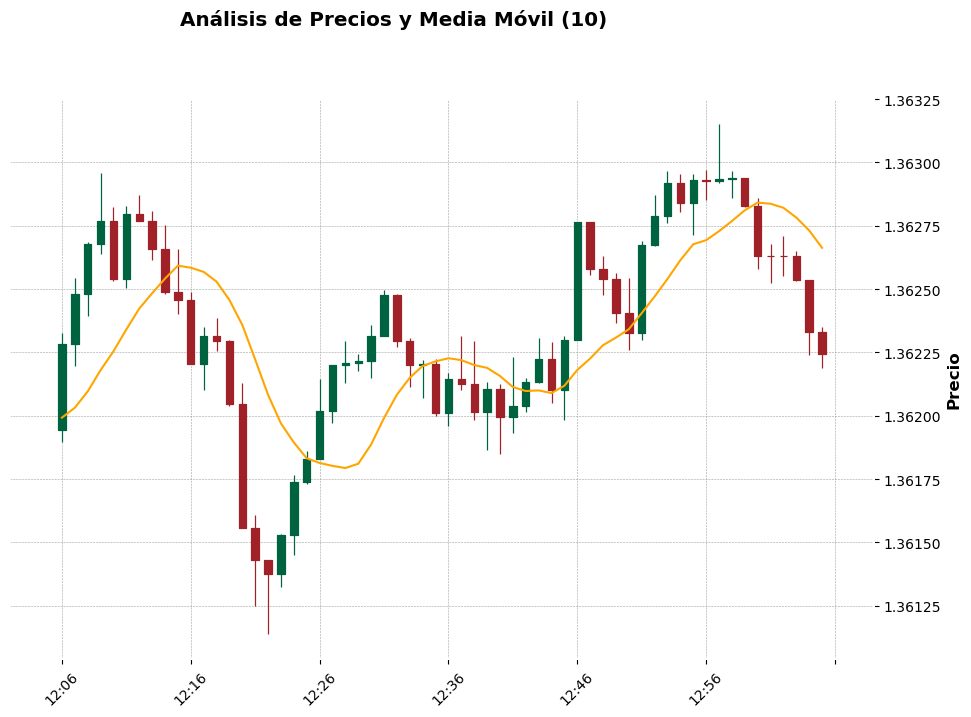

In [ ]:
# Llamada a la función para mostrar el gráfico
velas(df_div, av_period)

In [ ]:
def simulation(df):
    "Simula una estrategia de trading basada en umbrales dinámicos de compra y venta, con gestión de riesgos y visualización de resultados."
    "Parámetros:\n"
    "df: DataFrame con los datos de precios (debe contener una columna 'close')"
    "Retorna:\n"
    "historial: Lista con los eventos de trading simulados"
    "Explicación:\n"
    "La función simula una estrategia de trading basada en umbrales dinámicos de compra y venta, con gestión de riesgos y visualización de resultados."
    # --- 1. Arreglo de Datos ---
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        df.set_index('date', inplace=True)
    df = df.sort_index()

    # --- 2. Variables de la Estrategia (AJUSTADAS PARA MÁS MOVIMIENTO) ---
    dinero = 10000.0  # Aumentamos base para ver mejor decimales
    producto = 0.0
    compras_seguidas = 0
    esperando_recuperacion = False
    
    # SENSIBILIDAD: Reducimos los umbrales para que se activen más seguido
    # High: 1.5% arriba | Low: 1.0% abajo
    UP_FACTOR = 1.02
    DOWN_FACTOR = 0.9995 
    
    precio_base = df['close'].iloc[0]
    high_target = precio_base * UP_FACTOR
    low_target = precio_base * DOWN_FACTOR
    precio_primera_compra = 0.0
    
    historial = []

    # --- 3. Bucle de Simulación ---
    for i in range(len(df)):
        precio_actual = df['close'].iloc[i]
        fecha = df.index[i]
        evento = None

        if esperando_recuperacion:
            # Recuperación: Bajamos el listón para volver a entrar más rápido
            if precio_actual >= precio_primera_compra*0.96 : 
                if dinero > 0:
                    inversion = dinero * 0.95 # Invertimos casi todo
                    producto += inversion / precio_actual
                    dinero -= inversion
                    high_target = precio_actual * UP_FACTOR
                    low_target = precio_actual * DOWN_FACTOR
                    esperando_recuperacion = False
                    compras_seguidas = 0
                    evento = 'COMPRA_RECUPERACION'
        else:
            # Lógica de VENTA (High)
            if precio_actual >= high_target:
                if producto > 0:
                    cantidad_a_vender = producto * 0.80 # Vendemos el 80%
                    dinero += cantidad_a_vender * precio_actual
                    producto -= cantidad_a_vender
                    
                    # Nuevos topes: Reseteamos targets desde el nuevo precio alto
                    high_target = precio_actual * UP_FACTOR
                    low_target = precio_actual * DOWN_FACTOR
                    
                    compras_seguidas = 0
                    evento = 'VENTA_PARCIAL'

            # Lógica de COMPRA (Low)
            elif precio_actual <= low_target:
                if compras_seguidas < 3:
                    if dinero > 0:
                        inversion = dinero * 0.50 # Compras escalonadas del 50% del cash
                        producto += inversion / precio_actual
                        dinero -= inversion
                        
                        if compras_seguidas == 0:
                            precio_primera_compra = precio_actual
                        
                        # Ajustamos targets para intentar comprar más abajo o vender rápido
                        high_target = precio_actual * 1.01 # Target de salida más cercano
                        low_target = precio_actual * 0.99
                        
                        compras_seguidas += 1
                        evento = 'COMPRA'
                else:
                    # Cuarta caída: Liquidamos para proteger capital
                    dinero += producto * precio_actual
                    producto = 0
                    esperando_recuperacion = True
                    evento = 'VENTA_TOTAL_PANICO'

        historial.append({
            'date': fecha, 'close': precio_actual, 'dinero': dinero,
            'producto': producto, 'total_wallet': dinero + (producto * precio_actual),
            'evento': evento, 'high_target': high_target, 'low_target': low_target
        })

    # --- 4. Visualización ---
    res_df = pd.DataFrame(historial).set_index('date')
    fig, (ax_price, ax_wallet) = plt.subplots(2, 1, figsize=(15, 10), sharex=True,gridspec_kw={'height_ratios': [2, 1]})

    ax_price.plot(res_df.index, res_df['close'], color='black', alpha=0.3, label='Precio')
    ax_price.plot(res_df.index, res_df['high_target'], color='green', linestyle=':', alpha=0.4)
    ax_price.plot(res_df.index, res_df['low_target'], color='red', linestyle=':', alpha=0.4)

    compras = res_df[res_df['evento'].str.contains('COMPRA', na=False)]
    ventas = res_df[res_df['evento'].str.contains('VENTA', na=False)]
    venta_panico = res_df[res_df['evento'].str.contains('PANICO', na=False)]
    compra_recuperacion = res_df[res_df['evento'].str.contains('RECUPERACION', na=False)]
    
    ax_price.scatter(compras.index, compras['close'], color='lime', marker='^', s=80, label='Compra', zorder=5)
    ax_price.scatter(ventas.index, ventas['close'], color='red', marker='v', s=80, label='Venta', zorder=5)
    ax_price.scatter(venta_panico.index, venta_panico['close'], color='orange', marker='x', s=80, label='Venta Panico', zorder=5)   
    ax_price.scatter(compra_recuperacion.index, compra_recuperacion['close'], color='purple', marker='o', s=80, label='Compra Recuperación', zorder=5)   
    ax_price.set_title("Simulación: Alta Frecuencia de Movimientos: Beneficios totales={:.2f}".format((res_df['total_wallet'].iloc[-1]-res_df['total_wallet'].iloc[0])*100/dinero)+"%")
    ax_price.legend()

    ax_wallet.plot(res_df.index, res_df['total_wallet'], color='blue', linewidth=2)
    ax_wallet.set_ylabel("Valor Cartera ($)")
    
    plt.tight_layout()
    plt.show()
    return res_df

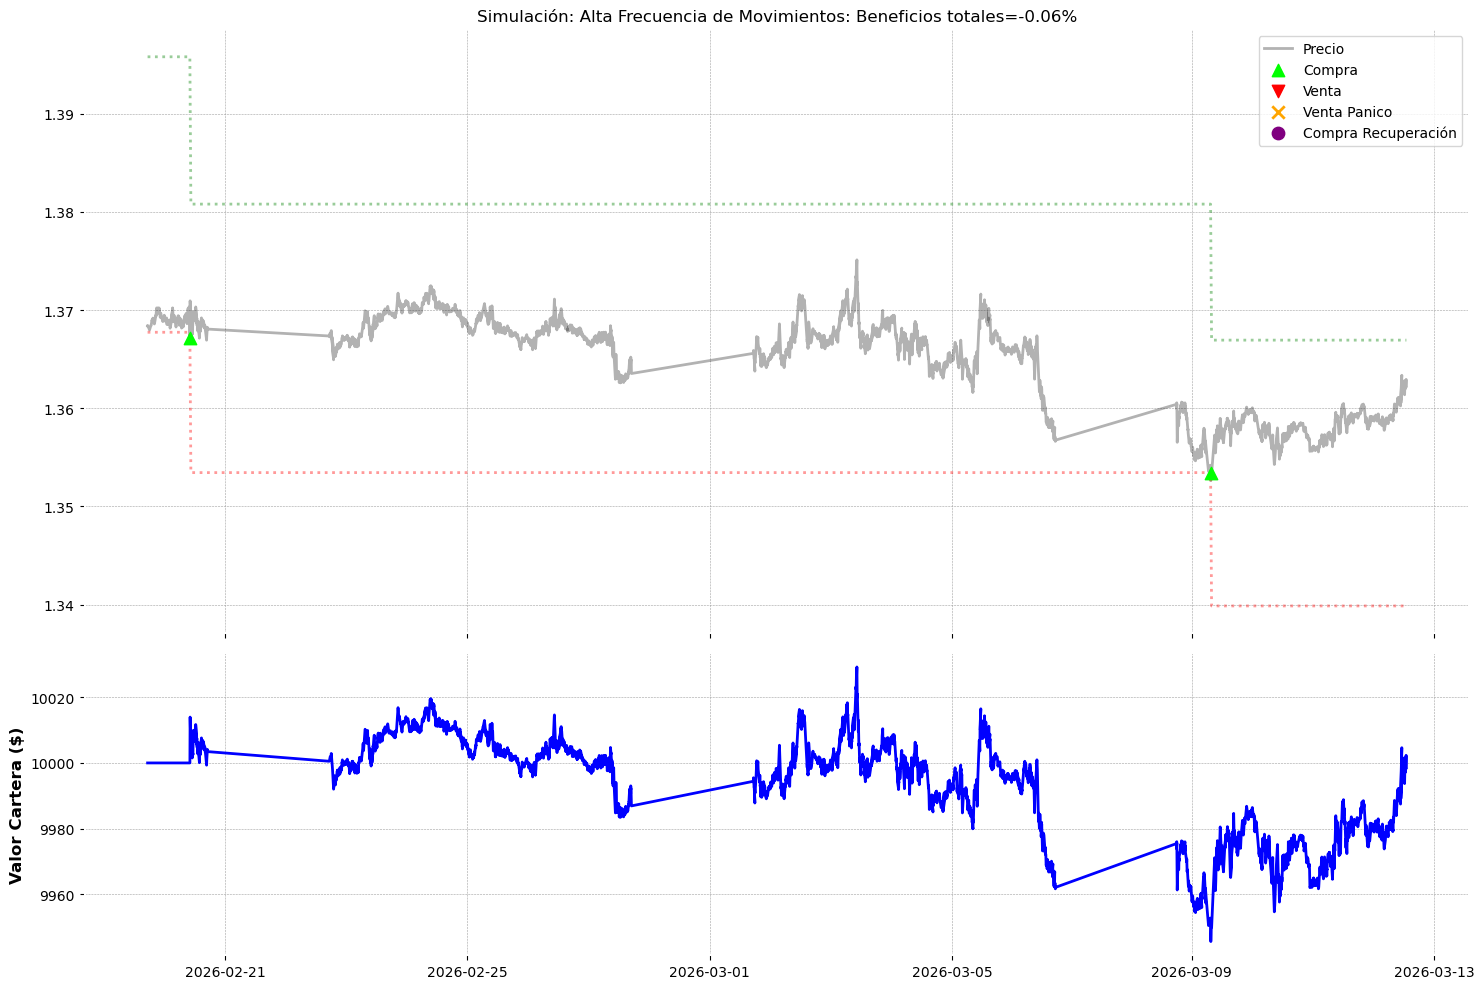

,close,dinero,producto,total_wallet,evento,high_target,low_target
date,,,,,,,
2026-02-19 17:15:00-05:00,1.368425,10000.0,0.000000,10000.000000,None,1.395794,1.367741
2026-02-19 17:16:00-05:00,1.368435,10000.0,0.000000,10000.000000,None,1.395794,1.367741
2026-02-19 17:17:00-05:00,1.368430,10000.0,0.000000,10000.000000,None,1.395794,1.367741
2026-02-19 17:18:00-05:00,1.368320,10000.0,0.000000,10000.000000,None,1.395794,1.367741
2026-02-19 17:19:00-05:00,1.368320,10000.0,0.000000,10000.000000,None,1.395794,1.367741
...,...,...,...,...,...,...,...
2026-03-12 13:01:00-04:00,1.362630,2500.0,5504.516245,10000.618972,None,1.366939,1.339871
2026-03-12 13:02:00-04:00,1.362630,2500.0,5504.516245,10000.618972,None,1.366939,1.339871
2026-03-12 13:03:00-04:00,1.362535,2500.0,5504.516245,10000.096043,None,1.366939,1.339871


In [ ]:
# Ejecutar la simulación con el DataFrame de precios
simulation(df_div)

In [ ]:
def simulation_interactiva(df):
    "Simula una estrategia de trading con visualización interactiva en tiempo real."
    "Parámetros:\n"
    "df: DataFrame con los datos de precios (debe contener una columna 'close')"
    "Retorna:\n"
    "None (visualiza los resultados en tiempo real)"
    "Explicación:\n"
    "La función simula una estrategia de trading con visualización interactiva en tiempo real."
    # --- 1. Preparación ---
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        df.set_index('date', inplace=True)
    
    # --- 2. Variables ---
    dinero_inicial = 10000.0
    dinero = dinero_inicial
    producto = 0.0
    compras_seguidas = 0
    esperando_recuperacion = False
    UP_FACTOR, DOWN_FACTOR = 1.02, 0.9995 
    
    precio_base = df['close'].iloc[0]
    high_target, low_target = precio_base * UP_FACTOR, precio_base * DOWN_FACTOR
    precio_primera_compra = 0.0
    
    precios_x, precios_y = [], []
    compra_x, compra_y = [], []
    venta_x, venta_y = [], []
    panic_x, panic_y = [], []
    recup_x, recup_y = [], []
    
    wallet_y = []
    historial_high, historial_low = [], []
    listado_eventos = []

    # --- 3. Bucle de Simulación ---
    for i in range(len(df)):
        precio_actual = df['close'].iloc[i]
        fecha = df.index[i]
        evento = None

        if esperando_recuperacion:
            if precio_actual >= precio_primera_compra:
                if dinero > 0:
                    inversion = dinero * 0.95
                    producto += inversion / precio_actual
                    dinero -= inversion
                    high_target, low_target = precio_actual * UP_FACTOR, precio_actual * DOWN_FACTOR
                    esperando_recuperacion, compras_seguidas = False, 0
                    evento = 'RECUPERACIÓN'
                    recup_x.append(fecha); recup_y.append(precio_actual)
        else:
            if precio_actual >= high_target:
                if producto > 0:
                    cant = producto * 0.80
                    dinero += cant * precio_actual
                    producto -= cant
                    high_target, low_target = precio_actual * UP_FACTOR, precio_actual * DOWN_FACTOR
                    compras_seguidas = 0
                    evento = 'VENTA PARCIAL'
                    venta_x.append(fecha); venta_y.append(precio_actual)
            elif precio_actual <= low_target:
                if compras_seguidas < 3:
                    if dinero > 0:
                        inversion = dinero * 0.50
                        producto += inversion / precio_actual
                        dinero -= inversion
                        if compras_seguidas == 0: precio_primera_compra = precio_actual
                        high_target, low_target = precio_actual * 1.01, precio_actual * 0.99
                        compras_seguidas += 1
                        evento = 'COMPRA'
                        compra_x.append(fecha); compra_y.append(precio_actual)
                else:
                    dinero += producto * precio_actual
                    producto = 0
                    esperando_recuperacion = True
                    evento = 'PÁNICO'
                    panic_x.append(fecha); panic_y.append(precio_actual)

        listado_eventos.append(evento)
        precios_x.append(fecha)
        precios_y.append(precio_actual)
        wallet_y.append(dinero + (producto * precio_actual))
        historial_high.append(high_target)
        historial_low.append(low_target)

        # --- 4. Dibujo ---
        if i % 2 == 0 or i == len(df) - 1:
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True, 
                                           gridspec_kw={'height_ratios': [2, 1]})
            
            # Gráfico de Precio
            ax1.plot(precios_x, precios_y, color='black', alpha=0.3, label='Precio')
            ax1.plot(precios_x, historial_high, color='green', ls=':', alpha=0.5, label='Nivel Venta')
            ax1.plot(precios_x, historial_low, color='red', ls=':', alpha=0.5, label='Nivel Compra')
            
            # Dibujamos los puntos acumulados (si existen)
            if compra_x:
                ax1.scatter(compra_x, compra_y, color='lime', marker='^', s=100, label='Señal: COMPRA', zorder=5)
            if venta_x:
                ax1.scatter(venta_x, venta_y, color='red', marker='v', s=100, label='Señal: VENTA', zorder=5)
            if panic_x:
                ax1.scatter(panic_x, panic_y, color='orange', marker='x', s=120, label='Señal: PÁNICO', zorder=6)
            if recup_x:
                ax1.scatter(recup_x, recup_y, color='purple', marker='o', s=100, label='Señal: RECUPERACIÓN', zorder=6)
            
            beneficio_porcentaje = (wallet_y[-1] - dinero_inicial) * 100 / dinero_inicial
            evento_actual = listado_eventos[-1] if listado_eventos[-1] is not None else "Analizando..."
            
            ax1.set_title(f"BENEFICIO: {beneficio_porcentaje:.2f} % | Último Evento: {evento_actual}")
            ax1.legend(loc='upper left', frameon=True, shadow=True)

            # Gráfico de Cartera
            ax2.plot(precios_x, wallet_y, color='blue', lw=2, label='Patrimonio Total')
            # ax2.fill_between(precios_x, wallet_y, color='blue', alpha=0.1)
            ax2.set_ylabel("Valor Cartera ($)")
            
            clear_output(wait=True)
            display(fig)
            
            if i < len(df) - 1:
                plt.close(fig)
                time.sleep(0.01)

    return pd.DataFrame({'wallet': wallet_y}, index=precios_x)

In [ ]:
# # Ejecuta con:
# res = simulation_interactiva(df_div)

In [ ]:
def dia_anterior(df):
    "Calcula el rango de precios (high y low) del día anterior al último registro del DataFrame."
    "Parámetros:\n"
    "df: DataFrame con los datos de precios (debe contener columnas 'high' y 'low')"
    "Retorna:\n"
    "df: DataFrame actualizado\n"
    "prev_high: Rango máximo del día anterior\n"
    "prev_low: Rango mínimo del día anterior"
    prev_day = df.index[-2].date()
    prev_data = df[df.index.date == prev_day]
    prev_high = prev_data['high'].max()
    prev_low = prev_data['low'].min()
    print(f"Rango anterior: High={prev_high}, Low={prev_low}")
    return df, prev_high, prev_low

In [ ]:
# Cálculo del rango del día anterior
df_div, prev_high, prev_low = dia_anterior(df_div)

Rango anterior: High=1.363415, Low=1.357675


In [ ]:
# Obtener el precio actual (último cierre)
current_price = df_div['close'].iloc[-1]

In [ ]:
    """
    Envia una orden a mercado con stop-loss dinámico y break-even para acciones, futuros o divisas.
    Contract: Objeto Contract de IB
    side: 'BUY' o 'SELL'
    precio_entrada: Precio al que se ejecutó la orden de mercado
    atr: Valor del ATR para calcular el stop-loss
    ib_instance: Instancia de IB para colocar órdenes
    cantidad: Número de contratos a operar (default=10, pero definir con stake de kelly)
    """

In [ ]:
def enviar_orden_con_stops(contract, side, atr, ib_instance, cantidad=10):
    "Envia una orden a mercado con stop-loss dinámico y break-even para acciones, futuros o divisas."
    "Parámetros:\n"
    "contract: Objeto Contract de IB\n"
    "side: 'BUY' o 'SELL'\n"
    "atr: Valor del ATR para calcular el stop-loss\n"
    "ib_instance: Instancia de IB para colocar órdenes\n"
    "cantidad: Número de contratos a operar (default=10, pero definir con stake de kelly)\n"
    "Retorna:\n"
    "Nada (coloca órdenes en IB)\n"
    "Explicación:\n"
    "Esta función envía una orden de mercado y coloca un stop-loss dinámico junto con un break-even."

    log(f"\n📤 Enviando orden {side} {cantidad} {contract.localSymbol}...")

    # Validar ATR
    if atr is None or math.isnan(atr):
        log("⚠️ Valor ATR inválido (NaN). No se puede colocar stop dinámico.")
        orden_mercado = MarketOrder(side, cantidad, outsideRth=True)
        trade = ib_instance.placeOrder(contract, orden_mercado)
        ib_instance.sleep(3)
        if trade.orderStatus.status != 'Filled':
            log(f"⚠️ Orden no ejecutada. Estado: {trade.orderStatus.status}")
            return
        log(f"✅ Entrada ejecutada a {trade.orderStatus.avgFillPrice:.2f} (sin stops por ATR inválido)")
        return

    # Enviar orden de mercado
    orden_mercado = MarketOrder(side, cantidad, outsideRth=True)
    trade = ib_instance.placeOrder(contract, orden_mercado)
    ib_instance.sleep(3)

    if trade.orderStatus.status != 'Filled':
        log(f"⚠️ Orden no ejecutada. Estado: {trade.orderStatus.status}")
        return

    precio_fill = trade.orderStatus.avgFillPrice
    log(f"✅ Entrada ejecutada a {precio_fill}")

    # Calcular niveles de stop y breakeven
    if side == 'BUY':
        stop_price = precio_fill - atr * risk_multiple
        break_even_trigger = precio_fill + atr * breakeven_trigger
        stop_side = 'SELL'
    else:
        stop_price = precio_fill + atr * risk_multiple
        break_even_trigger = precio_fill - atr * breakeven_trigger
        stop_side = 'BUY'

    # Validar el precio del stop
    if stop_price is None or math.isnan(stop_price) or stop_price <= 0:
        log("⚠️ Stop price inválido, no se coloca orden de stop.")
        return

    # Colocar orden stop
    stop_order = StopOrder(stop_side, cantidad, stop_price, outsideRth=False)
    stop_trade = ib_instance.placeOrder(contract, stop_order)
    ib_instance.sleep(2)

    log(f"🛑 Stop inicial colocado en {stop_price}")

    log(f"📡 Monitoreando para activar break-even si supera {break_even_trigger}...")

    for _ in range(300):
        ib_instance.sleep(2)
        ticker = ib_instance.reqMktData(contract, '', False, False)
        ib_instance.sleep(1.5)
        current_price = ticker.marketPrice()
        ib_instance.cancelMktData(contract)

        if current_price is None or current_price == 0 or math.isnan(current_price):
            continue

        log(f"💹 Precio actual: {current_price}")

        if (side == 'BUY' and current_price >= break_even_trigger) or \
           (side == 'SELL' and current_price <= break_even_trigger):

            log("🔔 Activando break-even...")

            # Verifica si la orden aún no fue cancelada o ejecutada
            ib_instance.sleep(0.5)
            stop_status = stop_trade.orderStatus.status
            if stop_status not in ['Cancelled', 'Filled']:
                try:
                    ib_instance.cancelOrder(stop_order)
                    ib_instance.sleep(1)
                except Exception as e:
                    log(f"⚠️ Error al cancelar la orden stop: {e}")
            else:
                log(f"⚠️ No se canceló el stop porque su estado es: {stop_status}")

            breakeven_stop = StopOrder(stop_side, cantidad, precio_fill, outsideRth=True)
            ib_instance.placeOrder(contract, breakeven_stop)
            log(f"🔒 Nuevo stop en punto de entrada: {precio_fill}")
            break


In [24]:
def breakout_entry_handler(df, contract, ib_instance, current_price, prev_high, prev_low, atr_period, risk_multiple, quantity):
    '''
     Maneja la lógica de entrada por breakout con stops dinámicos basados en ATR.
    df: DataFrame con datos históricos
    contract: Objeto Contract de IB
    ib_instance: Instancia de IB para colocar órdenes
    current_price: Precio actual del activo
    prev_high: High anterior
    prev_low: Low anterior
    atr_period: Período para calcular el ATR
    risk_multiple: Múltiplo de riesgo para el stop-loss
    quantity: Cantidad de contratos a operar
    upper_threshold: Umbral superior para señal de compra
    lower_threshold: Umbral inferior para señal de venta
    venta_panico: Variable para marcar si se ha activado la venta por pánico
    compra_recuperacion: Variable para marcar si se ha activado la compra de recuperación
    '''
    # Calcular ATR reutilizando la lógica de senal() de la práctica 2
    df['H-L'] = df['high'] - df['low']
    df['H-PC'] = abs(df['high'] - df['close'].shift(1))
    df['L-PC'] = abs(df['low'] - df['close'].shift(1))
    df['TR'] = df[['H-L', 'H-PC', 'L-PC']].max(axis=1)
    df['ATR'] = df['TR'].rolling(window=atr_period).mean()

    atr = df['ATR'].iloc[-1]
    upper_threshold = prev_high + buffer
    lower_threshold = prev_low - buffer

    if atr is None or math.isnan(atr):
        log("⚠️ No se pudo calcular ATR válido para la señal.")
        return

    buffer = atr * 0.1  # buffer del 10% del ATR para filtrar ruido

    log(f"\n📊 Precio actual: {current_price:.5f} | High anterior: {prev_high:.5f} | Low anterior: {prev_low:.5f} | ATR: {atr:.5f} | Buffer: {buffer:.5f}")

    #Posibles casos de venta, compra o espera

    if df['Sube'].iloc[-1] == 1 and current_price > (upper_threshold):
        log("📈 Señal de breakout al alza")
        enviar_orden_con_stops(contract, 'BUY', atr, ib_instance, cantidad=quantity)

    elif df['Sube'].iloc[-1] == 0 and current_price < (lower_threshold):
        log("📉 Señal de breakout a la baja")
        enviar_orden_con_stops(contract, 'SELL',  atr, ib_instance, cantidad=quantity)

    else:

        log("⏸️ No hay señal de breakout.")
        log(f"🔍 Esperando condiciones de entrada...")
        log(f"📌 Precio debe superar {upper_threshold:.5f} para BUY o caer por debajo de {lower_threshold:.5f} para SELL.")

In [26]:
def breakout_entry_handler_v2(df, contract, ib_instance, current_price, prev_high, prev_low, atr_period, risk_multiple, quantity):
    '''
     Maneja la lógica de entrada por breakout con stops dinámicos basados en ATR.
    df: DataFrame con datos históricos
    contract: Objeto Contract de IB
    ib_instance: Instancia de IB para colocar órdenes
    current_price: Precio actual del activo
    prev_high: High anterior
    prev_low: Low anterior
    atr_period: Período para calcular el ATR
    risk_multiple: Múltiplo de riesgo para el stop-loss
    quantity: Cantidad de contratos a operar
    upper_threshold: Umbral superior para señal de compra
    lower_threshold: Umbral inferior para señal de venta
    venta_panico: Variable para marcar si se ha activado la venta por pánico
    compra_recuperacion: Variable para marcar si se ha activado la compra de recuperación
    '''
    # Calcular ATR reutilizando la lógica de senal() de la práctica 2
    df['H-L'] = df['high'] - df['low']
    df['H-PC'] = abs(df['high'] - df['close'].shift(1))
    df['L-PC'] = abs(df['low'] - df['close'].shift(1))
    df['TR'] = df[['H-L', 'H-PC', 'L-PC']].max(axis=1)
    df['ATR'] = df['TR'].rolling(window=atr_period).mean()
    df['Sube'] = (df['close'] > df['close'].shift(1)).astype(int)
    #Compras seguidas y venta por pánico junto con factores de compra y venta más agresivos para generar más señales y probar la lógica de recuperación
    compras_seguidas = 0
    esperando_recuperacion = False
    UP_FACTOR, DOWN_FACTOR = 1.02, 0.9995 
    atr = df['ATR'].iloc[-1]
    # upper_threshold = prev_high + buffer
    # lower_threshold = prev_low - buffer
    try:
        while True:
            # --- 2. CONSULTA DE DINERO Y CARTERA ---
            presupuesto_disponible = 0
            for entry in ib_instance.accountSummary():
                if entry.tag == 'NetLiquidation':
                    presupuesto_disponible = float(entry.value)
                    print(f"💰 Saldo actual: {presupuesto_disponible} {entry.currency}")
            # Obtener todas las posiciones actuales
            positions = ib_instance.positions()
            # Filtrar por el contrato actual (asumiendo que tienes la variable 'contract')
            current_pos = [p for p in positions if p.contract.symbol == contract.symbol]
            if current_pos:
                for p in current_pos:
                    print(f"📦 Cantidad de {p.contract.symbol}: {p.position}")
                    producto_en_cartera = p.position
            else:
                print(f"📦 No tienes posiciones abiertas de {contract.symbol}")

            if atr is None or math.isnan(atr):
                log("⚠️ No se pudo calcular ATR válido para la señal.")
                return

            buffer = atr * 0.1  # buffer del 10% del ATR para filtrar ruido

            log(f"\n📊 Precio actual: {current_price:.5f} | High anterior: {prev_high:.5f} | Low anterior: {prev_low:.5f} | ATR: {atr:.5f} | Buffer: {buffer:.5f}")

            #Posibles casos de venta, compra o espera

            if df['Sube'].iloc[-1] == 1 and current_price > (UP_FACTOR*prev_high):
                log("📈 Señal de breakout al alza")
                enviar_orden_con_stops(contract, 'BUY', atr, ib_instance, cantidad=quantity)
                compras_seguidas += 1

            elif df['Sube'].iloc[-1] == 0 and current_price < (DOWN_FACTOR*prev_low):
                log("📉 Señal de breakout a la baja")
                enviar_orden_con_stops(contract, 'SELL',  atr, ib_instance, cantidad=quantity)
                compras_seguidas = 0 
            elif compras_seguidas >= 3:
                log("⚠️ Se han realizado 3 compras seguidas sin recuperación. Activando venta por pánico.")
                enviar_orden_con_stops(contract, 'SELL', atr, ib_instance, cantidad=quantity)
                esperando_recuperacion = True
                compras_seguidas = 0
            elif esperando_recuperacion and current_price >= (prev_low * 0.96):
                log("🔔 Condición de recuperación alcanzada. Intentando nueva compra.")
                enviar_orden_con_stops(contract, 'BUY', atr, ib_instance, cantidad=quantity)
                esperando_recuperacion = False
                compras_seguidas = 0
            else:
                log("⏸️ No hay señal de breakout.")
                log(f"🔍 Esperando condiciones de entrada...")
                log(f"📌 Precio debe superar {UP_FACTOR*prev_high:.5f} para BUY o caer por debajo de {DOWN_FACTOR*prev_low:.5f} para SELL.")
            ib_instance.sleep(2)  # Espera antes de volver a evaluar

            # --- 3. CONDICIÓN DE PARADA: SIN DINERO ---
            # Ajusta el '100' por el mínimo que requiera tu activo para operar
            if presupuesto_disponible < 100: 
                log("❌ Saldo insuficiente para continuar operando. Deteniendo bot.")
                break


    except KeyboardInterrupt:
        log("🛑 Bot detenido manualmente por el usuario.")

In [28]:
breakout_entry_handler_v2(df_div, div_contract, ib, current_price, prev_high, prev_low, atr_period, risk_multiple, quantity)

💰 Saldo actual: 1001574.26 USD
📦 No tienes posiciones abiertas de USD

📊 Precio actual: 1.36224 | High anterior: 1.36342 | Low anterior: 1.35767 | ATR: 0.00018 | Buffer: 0.00002
⏸️ No hay señal de breakout.
🔍 Esperando condiciones de entrada...
📌 Precio debe superar 1.39068 para BUY o caer por debajo de 1.35700 para SELL.
💰 Saldo actual: 1001574.26 USD
📦 No tienes posiciones abiertas de USD

📊 Precio actual: 1.36224 | High anterior: 1.36342 | Low anterior: 1.35767 | ATR: 0.00018 | Buffer: 0.00002
⏸️ No hay señal de breakout.
🔍 Esperando condiciones de entrada...
📌 Precio debe superar 1.39068 para BUY o caer por debajo de 1.35700 para SELL.
💰 Saldo actual: 1001574.26 USD
📦 No tienes posiciones abiertas de USD

📊 Precio actual: 1.36224 | High anterior: 1.36342 | Low anterior: 1.35767 | ATR: 0.00018 | Buffer: 0.00002
⏸️ No hay señal de breakout.
🔍 Esperando condiciones de entrada...
📌 Precio debe superar 1.39068 para BUY o caer por debajo de 1.35700 para SELL.
💰 Saldo actual: 1001574.26 U

In [ ]:
ib.disconnect()